<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-43-the-naive-bayes-classifier?scriptVersionId=346784456" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #1a0a00 0%, #2d1500 50%, #1a0f00 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #4a2800;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 43</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🔮 The Naive Bayes Classifier</h1>
  <p style="color: #fdba74; font-size: 16px; margin: 0 0 28px 0; max-width: 680px; line-height: 1.6;">A probabilistic family of classifiers built on Bayes' Theorem — fast, interpretable, and surprisingly effective despite a bold simplifying assumption. Covers all 5 sklearn variants with real datasets.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #4a2800; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #f97316; font-size: 20px; font-weight: 700;">5 Variants</div>
      <div style="color: #fdba74; font-size: 12px; margin-top: 2px;">Gaussian · Multinomial · Bernoulli · Categorical · Complement</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #4a2800; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #f97316; font-size: 20px; font-weight: 700;">3 Datasets</div>
      <div style="color: #fdba74; font-size: 12px; margin-top: 2px;">Iris · SMS Spam · Titanic</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #4a2800; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #f97316; font-size: 20px; font-weight: 700;">~99%</div>
      <div style="color: #fdba74; font-size: 12px; margin-top: 2px;">Spam detection accuracy</div>
    </div>
  </div>
</div>

<div style="background: #100800; border-left: 5px solid #f97316; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #4a2800; border-left: 5px solid #f97316;">
  <h2 style="color: #f97316; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <ol style="margin: 0; padding-left: 20px; color: #fb923c; line-height: 2.1; font-size: 14px;">
    <li><a href='#theory' style='color: #fb923c; text-decoration: none;'>Bayes' Theorem — The Foundation</a></li>
    <li><a href='#naive' style='color: #fb923c; text-decoration: none;'>Why "Naive"? — The Conditional Independence Assumption</a></li>
    <li><a href='#math' style='color: #fb923c; text-decoration: none;'>Mathematical Intuition</a></li>
    <li><a href='#variants' style='color: #fb923c; text-decoration: none;'>The 5 Variants — Which to Use When</a></li>
    <li><a href='#imports' style='color: #fb923c; text-decoration: none;'>Imports</a></li>
    <li><a href='#gaussian' style='color: #fb923c; text-decoration: none;'>GaussianNB — Iris Dataset (Continuous Features)</a></li>
    <li><a href='#multinomial' style='color: #fb923c; text-decoration: none;'>MultinomialNB — SMS Spam (Word Counts)</a></li>
    <li><a href='#bernoulli' style='color: #fb923c; text-decoration: none;'>BernoulliNB — SMS Spam (Binary Presence)</a></li>
    <li><a href='#categorical' style='color: #fb923c; text-decoration: none;'>CategoricalNB — Titanic (Categorical Features)</a></li>
    <li><a href='#complement' style='color: #fb923c; text-decoration: none;'>ComplementNB — SMS Spam (Imbalanced Text)</a></li>
    <li><a href='#compare' style='color: #fb923c; text-decoration: none;'>Model Comparison &amp; Cheat Sheet</a></li>
  </ol>
</div>

<a id='theory'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Bayes' Theorem — The Foundation</h2>
</div>

Naive Bayes is built entirely on **Bayes' Theorem** — a formula from probability theory that tells us how to update our belief about something after seeing evidence. Instead of asking "which class produces this data?", it asks "given this data, which class is most probable?"

<div style="background: #100800; border: 1px solid #4a2800; border-radius: 12px; padding: 26px 32px; margin: 20px 0;">
  <div style="color: #fdba74; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">Bayes' Theorem</div>
  <div style="text-align: center; margin-bottom: 20px;">
    <span style="color: #f97316; font-size: 24px; font-weight: 700; font-family: Georgia, serif;">P(y | X) = P(X | y) · P(y) / P(X)</span>
  </div>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; font-size: 13px;">
    <div style="background: rgba(249,115,22,0.1); border: 1px solid #4a2800; border-radius: 8px; padding: 12px 16px;">
      <div style="color: #f97316; font-weight: 700; font-size: 15px; font-family: Georgia, serif; margin-bottom: 6px;">P(y | X) — Posterior</div>
      <div style="color: #fdba74;">What we want: the probability of class y <strong>given</strong> the observed features X. This is what the classifier outputs.</div>
    </div>
    <div style="background: rgba(249,115,22,0.1); border: 1px solid #4a2800; border-radius: 8px; padding: 12px 16px;">
      <div style="color: #f97316; font-weight: 700; font-size: 15px; font-family: Georgia, serif; margin-bottom: 6px;">P(X | y) — Likelihood</div>
      <div style="color: #fdba74;">How probable is the data X given class y? Learned from the training set. Different variants model this differently.</div>
    </div>
    <div style="background: rgba(249,115,22,0.1); border: 1px solid #4a2800; border-radius: 8px; padding: 12px 16px;">
      <div style="color: #f97316; font-weight: 700; font-size: 15px; font-family: Georgia, serif; margin-bottom: 6px;">P(y) — Prior</div>
      <div style="color: #fdba74;">How common is class y in the training data? Estimated by class frequency. Biases the model toward common classes.</div>
    </div>
    <div style="background: rgba(249,115,22,0.1); border: 1px solid #4a2800; border-radius: 8px; padding: 12px 16px;">
      <div style="color: #f97316; font-weight: 700; font-size: 15px; font-family: Georgia, serif; margin-bottom: 6px;">P(X) — Evidence</div>
      <div style="color: #fdba74;">Probability of observing X at all. Acts as a normalising constant — same for all classes, so we can ignore it for classification.</div>
    </div>
  </div>
  <div style="margin-top: 16px; padding-top: 14px; border-top: 1px solid #4a2800; color: #f97316; font-size: 14px; text-align: center; font-family: Georgia, serif;">
    Decision rule: &nbsp; ŷ = argmax<sub>y</sub> &nbsp; P(X | y) · P(y)
  </div>
</div>

<a id='naive'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Why "Naive"? — The Conditional Independence Assumption</h2>
</div>

Computing `P(X | y)` for a full feature vector X is expensive — it requires estimating the joint distribution of all features, which grows exponentially. Naive Bayes makes the **bold (naive) assumption** that all features are conditionally independent given the class:

<div style="background: #100800; border: 1px solid #4a2800; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="color: #fdba74; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 14px;">The Naive Assumption</div>
  <div style="text-align: center; margin-bottom: 14px;">
    <span style="color: #f97316; font-size: 18px; font-family: Georgia, serif;">P(x₁, x₂, ..., xₙ | y) ≈ P(x₁|y) · P(x₂|y) · ... · P(xₙ|y)</span>
  </div>
  <div style="color: #fdba74; font-size: 13px; line-height: 1.7; text-align: center;">
    Instead of one hard joint distribution, we estimate <strong style='color:#fed7aa;'>n separate 1D distributions</strong> — one per feature. Massively simpler and faster.
  </div>
</div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin: 16px 0;">
  <div style="background: #100800; border: 1px solid #4a2800; border-top: 2px solid #e74c3c; border-radius: 0 0 8px 8px; padding: 14px 16px;">
    <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🤔 Is the assumption realistic?</div>
    <div style="color: #fdba74; font-size: 13px; line-height: 1.7;">Almost never. In spam detection, "free" and "win" are correlated — both appear together in spam. In Iris, petal length and petal width are strongly correlated. The independence assumption is violated in almost every real dataset.</div>
  </div>
  <div style="background: #100800; border: 1px solid #4a2800; border-top: 2px solid #22c55e; border-radius: 0 0 8px 8px; padding: 14px 16px;">
    <div style="color: #22c55e; font-weight: 700; font-size: 13px; margin-bottom: 6px;">✅ Why it works anyway</div>
    <div style="color: #fdba74; font-size: 13px; line-height: 1.7;">We don't need accurate probability estimates — we just need the right class ranking. Even with wrong probabilities, the argmax often selects the correct class. Naive Bayes is <strong style='color:#fed7aa;'>a good classifier but a bad probability estimator.</strong></div>
  </div>
</div>

<a id='math'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Mathematical Intuition — A Worked Example</h2>
</div>

Let's trace through a concrete spam detection example with 2 words: "free" and "win".

<div style="background: #100800; border: 1px solid #4a2800; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="color: #fdba74; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">Training Data Statistics</div>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin-bottom: 16px;">
    <div>
      <div style="color: #f97316; font-weight: 700; margin-bottom: 6px;">Prior probabilities</div>
      <div style="color: #fdba74; font-size: 13px; line-height: 1.8;">P(spam) = 0.30 &nbsp; (30% of emails are spam)<br/>P(ham)  = 0.70 &nbsp; (70% are legitimate)</div>
    </div>
    <div>
      <div style="color: #f97316; font-weight: 700; margin-bottom: 6px;">Likelihoods from training</div>
      <div style="color: #fdba74; font-size: 13px; line-height: 1.8;">
        P("free" | spam) = 0.80 &nbsp; P("free" | ham) = 0.10<br/>
        P("win"  | spam) = 0.70 &nbsp; P("win"  | ham) = 0.05
      </div>
    </div>
  </div>
  <div style="border-top: 1px solid #4a2800; padding-top: 14px;">
    <div style="color: #f97316; font-weight: 700; margin-bottom: 8px;">New email contains both words. Which class?</div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; font-size: 13px; font-family: Georgia, serif;">
      <div style="background: rgba(249,115,22,0.12); border: 1px solid #f97316; border-radius: 6px; padding: 10px 14px;">
        <div style="color: #f97316; font-weight: 700;">Score(spam):</div>
        <div style="color: #fed7aa;">0.80 × 0.70 × 0.30 = 0.168</div>
      </div>
      <div style="background: rgba(255,255,255,0.04); border: 1px solid #4a2800; border-radius: 6px; padding: 10px 14px;">
        <div style="color: #fdba74; font-weight: 700;">Score(ham):</div>
        <div style="color: #fdba74;">0.10 × 0.05 × 0.70 = 0.0035</div>
      </div>
    </div>
    <div style="margin-top: 10px; color: #22c55e; font-weight: 700; font-size: 14px;">→ spam score >> ham score → Predicted: SPAM ✅</div>
  </div>
</div>

<a id='variants'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">The 5 Variants — Which to Use When</h2>
</div>

The different Naive Bayes variants differ only in how they model `P(xᵢ | y)` — the likelihood of each feature given the class. Everything else (Bayes' theorem, independence assumption, argmax decision) is the same.

<div style="background: #100800; border: 1px solid #4a2800; border-radius: 10px; overflow: hidden; margin: 16px 0;">
  <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
    <thead>
      <tr style="background: #2d1500;">
        <th style="padding: 12px 16px; color: #f97316; text-align: left;">Variant</th>
        <th style="padding: 12px 16px; color: #f97316; text-align: left;">Likelihood Model</th>
        <th style="padding: 12px 16px; color: #f97316; text-align: left;">Feature Type</th>
        <th style="padding: 12px 16px; color: #f97316; text-align: left;">Use Case</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #4a2800;">
        <td style="padding: 11px 16px; font-weight: 700; color: #f97316;">🌸 GaussianNB</td>
        <td style="padding: 11px 16px; color: #fdba74;">Gaussian (bell curve) per feature per class</td>
        <td style="padding: 11px 16px; color: #fdba74;">Continuous numerical</td>
        <td style="padding: 11px 16px; color: #fdba74;">Medical measurements, sensor data, Iris</td>
      </tr>
      <tr style="border-bottom: 1px solid #4a2800; background: rgba(249,115,22,0.04);">
        <td style="padding: 11px 16px; font-weight: 700; color: #f97316;">📱 MultinomialNB</td>
        <td style="padding: 11px 16px; color: #fdba74;">Multinomial — models word count frequencies</td>
        <td style="padding: 11px 16px; color: #fdba74;">Integer counts (≥ 0)</td>
        <td style="padding: 11px 16px; color: #fdba74;">Text classification, spam detection</td>
      </tr>
      <tr style="border-bottom: 1px solid #4a2800;">
        <td style="padding: 11px 16px; font-weight: 700; color: #f97316;">📱 BernoulliNB</td>
        <td style="padding: 11px 16px; color: #fdba74;">Bernoulli — models word presence/absence only</td>
        <td style="padding: 11px 16px; color: #fdba74;">Binary 0/1</td>
        <td style="padding: 11px 16px; color: #fdba74;">Short text, document classification</td>
      </tr>
      <tr style="border-bottom: 1px solid #4a2800; background: rgba(249,115,22,0.04);">
        <td style="padding: 11px 16px; font-weight: 700; color: #f97316;">🚢 CategoricalNB</td>
        <td style="padding: 11px 16px; color: #fdba74;">Categorical — discrete label frequencies per class</td>
        <td style="padding: 11px 16px; color: #fdba74;">Categorical / ordinal</td>
        <td style="padding: 11px 16px; color: #fdba74;">Titanic features (Sex, Pclass, Embarked)</td>
      </tr>
      <tr style="background: rgba(249,115,22,0.04);">
        <td style="padding: 11px 16px; font-weight: 700; color: #f97316;">⚖️ ComplementNB</td>
        <td style="padding: 11px 16px; color: #fdba74;">Complement — learns from the other classes</td>
        <td style="padding: 11px 16px; color: #fdba74;">Counts (like Multinomial)</td>
        <td style="padding: 11px 16px; color: #fdba74;">Imbalanced text datasets</td>
      </tr>
    </tbody>
  </table>
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Imports</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB, ComplementNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

<a id='gaussian'></a>
<div style="background: #100800; border: 1px solid #4a2800; border-radius: 12px; padding: 20px 26px; margin: 32px 0 20px 0;">
  <div style="display: flex; align-items: center; gap: 12px;">
    <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Variant 1</span>
    <span style="background: #1a3a1a; color: #22c55e; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">🌸 Iris Dataset</span>
    <span style="background: #1a1a3a; color: #60a5fa; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">Continuous numerical features</span>
  </div>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 12px 0 0 0;">GaussianNB</h2>
</div>

**GaussianNB** assumes each feature follows a **Gaussian (normal) distribution** within each class. During training it estimates the mean (μ) and variance (σ²) of each feature per class. During prediction it plugs the input into the Gaussian PDF to compute the likelihood.

<div style="background: #100800; border: 1px solid #4a2800; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #fdba74;">
  <strong style="color: #f97316;">How it works:</strong> For each class k, it computes
  <span style="font-family: Georgia, serif; color: #fed7aa;"> P(xᵢ | y=k) = (1/√2πσ²) · exp(−(xᵢ−μ)²/2σ²)</span>.
  Then multiplies across all features and multiplies by the prior P(y=k).
</div>

In [2]:
iris_df = pd.read_csv("/kaggle/input/datasets/uciml/iris/Iris.csv")

print(f"Shape : {iris_df.shape}")
print(f"Classes: {iris_df['Species'].unique()}")
iris_df.head()

Shape : (150, 6)
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
X = iris_df.drop(columns=["Id", "Species"])
y = iris_df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y, test_size=0.25
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (112, 4)  |  Test: (38, 4)


In [4]:
model_gnb = GaussianNB()
model_gnb.fit(X_train, y_train)
y_pred = model_gnb.predict(X_test)

print(f"GaussianNB Accuracy : {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

GaussianNB Accuracy : 0.9211

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.86      0.92      0.89        13
 Iris-virginica       0.92      0.85      0.88        13

       accuracy                           0.92        38
      macro avg       0.92      0.92      0.92        38
   weighted avg       0.92      0.92      0.92        38



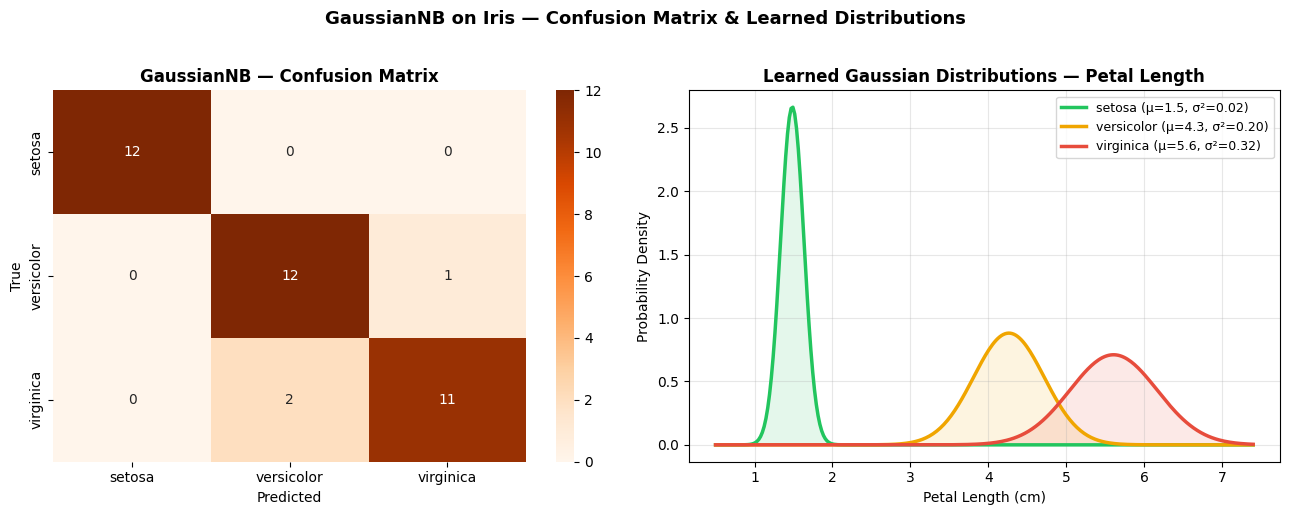

In [5]:
# Visualise: learned Gaussian distributions per class for Petal Length
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model_gnb.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=[c.replace('Iris-', '') for c in model_gnb.classes_],
            yticklabels=[c.replace('Iris-', '') for c in model_gnb.classes_])
axes[0].set_title('GaussianNB — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Gaussian distributions for Petal Length feature
x_range = np.linspace(iris_df['PetalLengthCm'].min() - 0.5, iris_df['PetalLengthCm'].max() + 0.5, 300)
petal_idx = list(X.columns).index('PetalLengthCm')
colors_cls = ['#22c55e', '#f0a500', '#e74c3c']

for i, (cls, color) in enumerate(zip(model_gnb.classes_, colors_cls)):
    mu  = model_gnb.theta_[i, petal_idx]
    var = model_gnb.var_[i, petal_idx]
    pdf = (1 / np.sqrt(2 * np.pi * var)) * np.exp(-0.5 * (x_range - mu)**2 / var)
    axes[1].plot(x_range, pdf, color=color, linewidth=2.5,
                 label=f'{cls.replace("Iris-","")} (μ={mu:.1f}, σ²={var:.2f})')
    axes[1].fill_between(x_range, pdf, alpha=0.12, color=color)

axes[1].set_title('Learned Gaussian Distributions — Petal Length', fontweight='bold')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('GaussianNB on Iris — Confusion Matrix & Learned Distributions',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="background: #100800; border-left: 4px solid #f97316; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #fdba74;">
  <strong style="color: #fed7aa;">✅ Key insight:</strong> The right plot shows the 3 learned Gaussian curves for Petal Length. Setosa's distribution is far-left with a narrow spread (short petals, consistent). Versicolor and Virginica overlap — that's where the ~8% error comes from. GaussianNB captures this overlap probabilistically.
</div>

<a id='multinomial'></a>
<div style="background: #100800; border: 1px solid #4a2800; border-radius: 12px; padding: 20px 26px; margin: 32px 0 20px 0;">
  <div style="display: flex; align-items: center; gap: 12px;">
    <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Variant 2</span>
    <span style="background: #1a1a3a; color: #60a5fa; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">📱 SMS Spam Dataset</span>
    <span style="background: #1a1a1a; color: #a78bfa; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">Word count features</span>
  </div>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 12px 0 0 0;">MultinomialNB</h2>
</div>

**MultinomialNB** models features as **word counts** — how many times each word appears in a document. It estimates P(word | class) as the fraction of all words in that class that are this word. A word appearing 5 times contributes 5× more evidence than one appearing once.

`CountVectorizer` converts raw text into a sparse matrix of word counts — one column per unique word in the vocabulary.

In [6]:
sms_df = pd.read_csv(
    "/kaggle/input/datasets/hamnawaseem112222222/sms-spam-collection-5572-labeled-sms-messages/sms_spam_collection (1).csv"
)

print(f"Shape  : {sms_df.shape}")
print(f"Class counts:\n{sms_df['label'].value_counts().to_string()}")
sms_df.head()

Shape  : (5572, 2)
Class counts:
label
ham     4825
spam     747


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
sms_df['label'] = sms_df['label'].map({'ham': 0, 'spam': 1})

X_sms = sms_df['message']
y_sms = sms_df['label']

X_train_sms, X_test_sms, y_train_sms, y_test_sms = train_test_split(
    X_sms, y_sms, test_size=0.2, random_state=42, stratify=y_sms
)
print(f"Train: {len(X_train_sms)}  |  Test: {len(X_test_sms)}")
print(f"Test class balance — ham: {(y_test_sms==0).sum()}, spam: {(y_test_sms==1).sum()}")

Train: 4457  |  Test: 1115
Test class balance — ham: 966, spam: 149


In [8]:
# CountVectorizer: word → integer count
vec_multi = CountVectorizer()
X_train_multi = vec_multi.fit_transform(X_train_sms)
X_test_multi  = vec_multi.transform(X_test_sms)

print(f"Vocabulary size : {len(vec_multi.vocabulary_)} unique words")
print(f"Feature matrix shape : {X_train_multi.shape}")

Vocabulary size : 7668 unique words
Feature matrix shape : (4457, 7668)


In [9]:
model_mnb = MultinomialNB()
model_mnb.fit(X_train_multi, y_train_sms)
y_pred_mnb = model_mnb.predict(X_test_multi)

print(f"MultinomialNB Accuracy : {accuracy_score(y_test_sms, y_pred_mnb):.4f}\n")
print(classification_report(y_test_sms, y_pred_mnb, target_names=['Ham (0)', 'Spam (1)']))

MultinomialNB Accuracy : 0.9874

              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      0.99       966
    Spam (1)       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



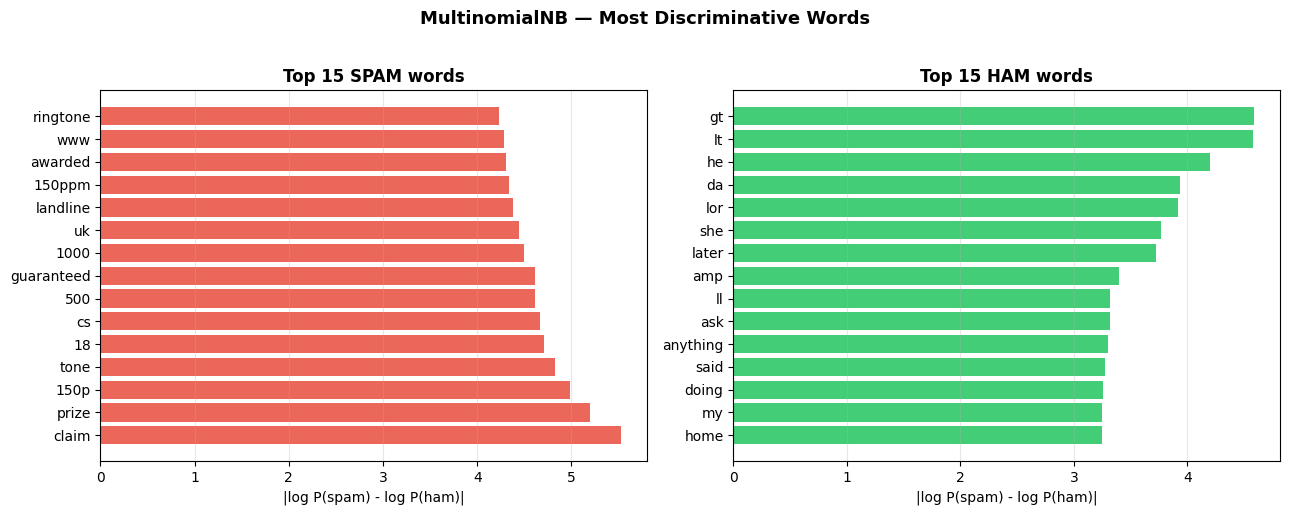

In [10]:
# Show the top words most indicative of spam vs ham
feature_names = np.array(vec_multi.get_feature_names_out())
log_probs = model_mnb.feature_log_prob_   # shape (2, n_features)
spam_minus_ham = log_probs[1] - log_probs[0]   # high = more spam-like

top_spam = feature_names[np.argsort(spam_minus_ham)[-15:][::-1]]
top_ham  = feature_names[np.argsort(spam_minus_ham)[:15]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, words, title, color in zip(
    axes,
    [top_spam, top_ham],
    ['Top 15 SPAM words', 'Top 15 HAM words'],
    ['#e74c3c', '#22c55e']
):
    scores = spam_minus_ham[np.isin(feature_names, words)]
    scores_sorted = spam_minus_ham[[np.where(feature_names == w)[0][0] for w in words]]
    ax.barh(range(len(words)), np.abs(scores_sorted[::-1] if title.startswith('Top 15 H') else scores_sorted),
            color=color, alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words[::-1] if title.startswith('Top 15 H') else words, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('|log P(spam) - log P(ham)|')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('MultinomialNB — Most Discriminative Words', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='bernoulli'></a>
<div style="background: #100800; border: 1px solid #4a2800; border-radius: 12px; padding: 20px 26px; margin: 32px 0 20px 0;">
  <div style="display: flex; align-items: center; gap: 12px;">
    <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Variant 3</span>
    <span style="background: #1a1a3a; color: #60a5fa; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">📱 SMS Spam Dataset</span>
    <span style="background: #1a1a1a; color: #a78bfa; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">Binary presence/absence</span>
  </div>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 12px 0 0 0;">BernoulliNB</h2>
</div>

**BernoulliNB** uses the same text, but converts counts to **binary 0/1** — a word either appears in the message or doesn't. Frequency is ignored. This works well for short messages where a word typically appears at most once anyway.

<div style="background: #100800; border: 1px solid #4a2800; border-radius: 10px; padding: 16px 22px; margin: 14px 0; overflow: hidden;">
  <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
    <thead>
      <tr style="background: #2d1500;">
        <th style="padding: 10px 14px; color: #f97316; text-align: left;">Model</th>
        <th style="padding: 10px 14px; color: #f97316; text-align: left;">"free" appears 3× in message</th>
        <th style="padding: 10px 14px; color: #f97316; text-align: left;">Feature value</th>
        <th style="padding: 10px 14px; color: #f97316; text-align: left;">Vectorizer setting</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #4a2800;">
        <td style="padding: 10px 14px; color: #fdba74; font-weight: 600;">MultinomialNB</td>
        <td style="padding: 10px 14px; color: #fdba74;">Count = 3</td>
        <td style="padding: 10px 14px; color: #fdba74;">3 (counts the occurrences)</td>
        <td style="padding: 10px 14px; color: #fdba74;"><code>binary=False</code> (default)</td>
      </tr>
      <tr style="background: rgba(249,115,22,0.06);">
        <td style="padding: 10px 14px; color: #fdba74; font-weight: 600;">BernoulliNB</td>
        <td style="padding: 10px 14px; color: #fdba74;">Present = 1</td>
        <td style="padding: 10px 14px; color: #fdba74;">1 (presence only)</td>
        <td style="padding: 10px 14px; color: #fdba74;"><code>binary=True</code></td>
      </tr>
    </tbody>
  </table>
</div>

In [11]:
# binary=True: word present → 1, absent → 0 (count ignored)
vec_bern = CountVectorizer(binary=True)
X_train_bern = vec_bern.fit_transform(X_train_sms)
X_test_bern  = vec_bern.transform(X_test_sms)

model_bnb = BernoulliNB()
model_bnb.fit(X_train_bern, y_train_sms)
y_pred_bnb = model_bnb.predict(X_test_bern)

print(f"BernoulliNB Accuracy : {accuracy_score(y_test_sms, y_pred_bnb):.4f}\n")
print(classification_report(y_test_sms, y_pred_bnb, target_names=['Ham (0)', 'Spam (1)']))

BernoulliNB Accuracy : 0.9758

              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.99       966
    Spam (1)       1.00      0.82      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



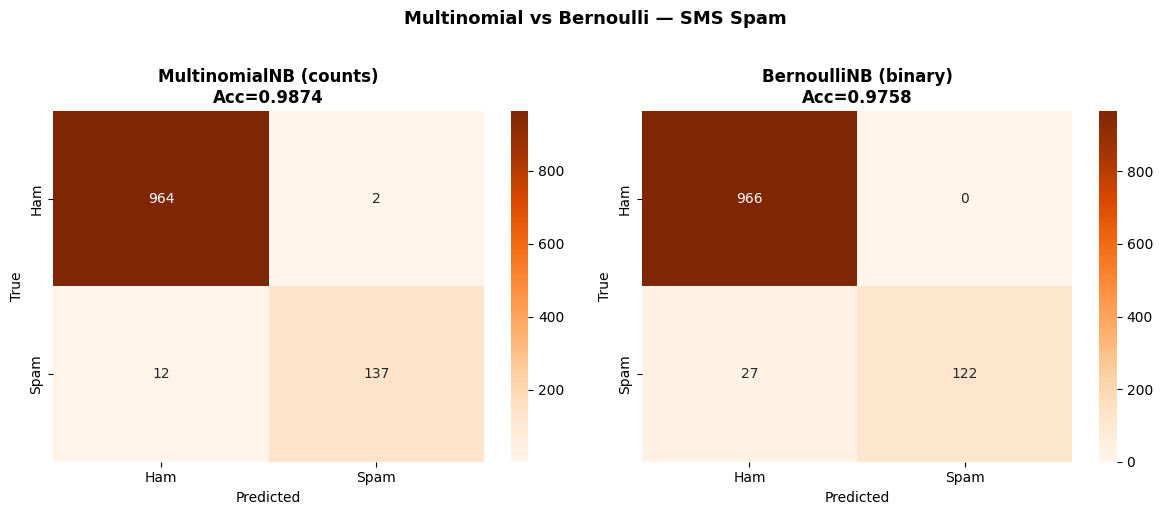

In [12]:
# Side-by-side confusion matrices: Multinomial vs Bernoulli
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_p, title in zip(
    axes,
    [y_pred_mnb, y_pred_bnb],
    ['MultinomialNB (counts)', 'BernoulliNB (binary)']
):
    cm = confusion_matrix(y_test_sms, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(f'{title}\nAcc={accuracy_score(y_test_sms, y_p):.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Multinomial vs Bernoulli — SMS Spam', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="background: #100800; border-left: 4px solid #f97316; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #fdba74;">
  <strong style="color: #fed7aa;">✅ Result:</strong> MultinomialNB (99%) outperforms BernoulliNB (97.6%) here. Spam messages tend to repeat words like "free", "win", "call" many times — so frequency carries real signal that Multinomial exploits and Bernoulli discards. For longer text, Multinomial generally wins.
</div>

<a id='categorical'></a>
<div style="background: #100800; border: 1px solid #4a2800; border-radius: 12px; padding: 20px 26px; margin: 32px 0 20px 0;">
  <div style="display: flex; align-items: center; gap: 12px;">
    <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Variant 4</span>
    <span style="background: #1a1a3a; color: #60a5fa; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">🚢 Titanic Dataset</span>
    <span style="background: #2a1a00; color: #fbbf24; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">Categorical features</span>
  </div>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 12px 0 0 0;">CategoricalNB</h2>
</div>

**CategoricalNB** is designed for features with discrete, unordered labels — like `Sex` (male/female), `Pclass` (1/2/3), or `Embarked` (S/C/Q). It estimates P(category | class) as a frequency count with Laplace smoothing, requiring all inputs to be **non-negative integers** (label-encoded).

In [13]:
titanic_df = pd.read_csv("/kaggle/input/datasets/ahmedfakhar123/titanic-survival-dataset/Titanic_Survival_Dataset.csv")

print(f"Shape  : {titanic_df.shape}")
print(f"\nMissing values:")
print(titanic_df.isnull().sum()[titanic_df.isnull().sum() > 0].to_string())

titanic_df.head()

Shape  : (891, 12)

Missing values:
Age         177
Cabin       687
Embarked      2


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
# Select categorical features, drop rows with missing values
cat_features = ['Pclass', 'Sex', 'Embarked']
titanic_clean = titanic_df[cat_features + ['Survived']].dropna()

print(f"After dropping nulls: {titanic_clean.shape}")
print(f"Survival rate: {titanic_clean['Survived'].mean():.3f}")

# Label encode all categorical columns (CategoricalNB needs non-negative integers)
le = LabelEncoder()
titanic_encoded = titanic_clean.copy()
for col in cat_features:
    titanic_encoded[col] = le.fit_transform(titanic_encoded[col])

print(f"\nEncoded sample:")
print(titanic_encoded.head())

After dropping nulls: (889, 4)
Survival rate: 0.382

Encoded sample:
   Pclass  Sex  Embarked  Survived
0       2    1         2         0
1       0    0         0         1
2       2    0         2         1
3       0    0         2         1
4       2    1         2         0


In [15]:
X_tit = titanic_encoded[cat_features]
y_tit = titanic_encoded['Survived']

X_train_tit, X_test_tit, y_train_tit, y_test_tit = train_test_split(
    X_tit, y_tit, test_size=0.2, random_state=42, stratify=y_tit
)

model_cnb = CategoricalNB()
model_cnb.fit(X_train_tit, y_train_tit)
y_pred_cnb = model_cnb.predict(X_test_tit)

print(f"CategoricalNB Accuracy : {accuracy_score(y_test_tit, y_pred_cnb):.4f}\n")
print(classification_report(y_test_tit, y_pred_cnb, target_names=['Did Not Survive', 'Survived']))

CategoricalNB Accuracy : 0.7865

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.82      0.83       110
       Survived       0.71      0.74      0.72        68

       accuracy                           0.79       178
      macro avg       0.77      0.78      0.78       178
   weighted avg       0.79      0.79      0.79       178



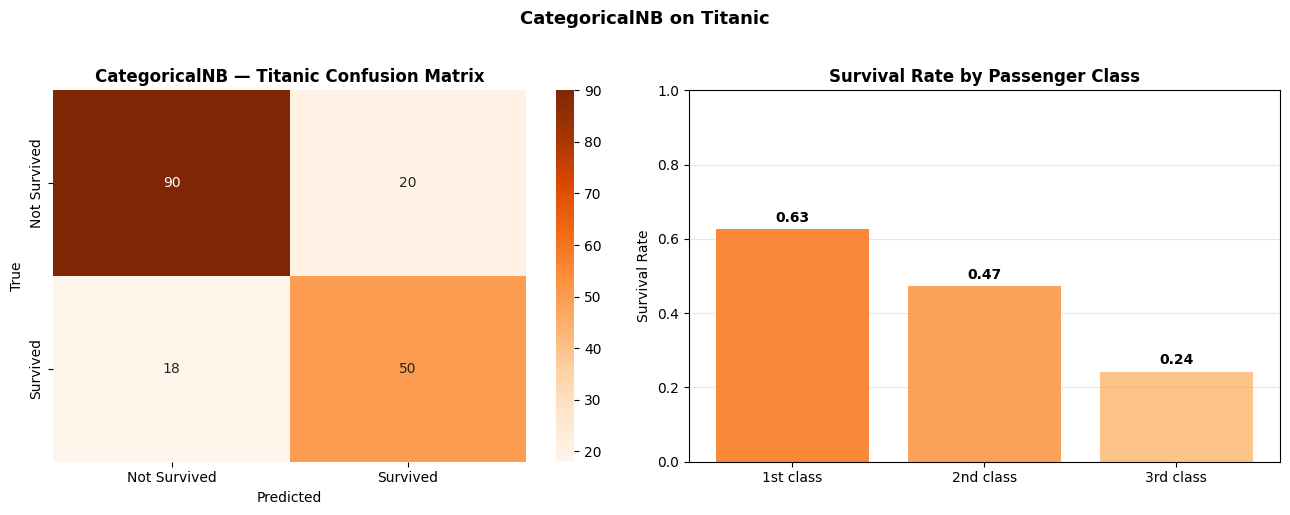

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test_tit, y_pred_cnb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
axes[0].set_title('CategoricalNB — Titanic Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Feature importance via survival rate
for col in cat_features:
    titanic_clean[col + '_enc'] = titanic_encoded[col]
survival_by_sex = titanic_clean.groupby('Sex')['Survived'].mean()
survival_by_cls = titanic_clean.groupby('Pclass')['Survived'].mean()
axes[1].bar(['1st class', '2nd class', '3rd class'],
            survival_by_cls.values, color=['#f97316', '#fb923c', '#fdba74'], alpha=0.85)
axes[1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(survival_by_cls.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('CategoricalNB on Titanic', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='complement'></a>
<div style="background: #100800; border: 1px solid #4a2800; border-radius: 12px; padding: 20px 26px; margin: 32px 0 20px 0;">
  <div style="display: flex; align-items: center; gap: 12px;">
    <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Variant 5</span>
    <span style="background: #1a1a3a; color: #60a5fa; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">📱 SMS Spam Dataset</span>
    <span style="background: #1a1a1a; color: #c084fc; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 4px;">Imbalanced text</span>
  </div>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 12px 0 0 0;">ComplementNB</h2>
</div>

**ComplementNB** is a variation of MultinomialNB specifically designed for **imbalanced datasets**. Instead of estimating P(word | class), it estimates P(word | complement of class) — i.e. how likely is this word given it is **NOT** this class. This corrects the bias that MultinomialNB develops when one class dominates.

<div style="background: #100800; border: 1px solid #4a2800; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #fdba74;">
  <strong style="color: #f97316;">Why it helps with imbalance:</strong> In our SMS dataset, ham messages (~87%) vastly outnumber spam (~13%). MultinomialNB's probability estimates are skewed by the dominant class. ComplementNB compensates by focusing on what makes each class <em>different from everything else</em>, producing more robust weight estimates.
</div>

In [17]:
vec_comp = CountVectorizer()
X_train_comp = vec_comp.fit_transform(X_train_sms)
X_test_comp  = vec_comp.transform(X_test_sms)

model_comp = ComplementNB()
model_comp.fit(X_train_comp, y_train_sms)
y_pred_comp = model_comp.predict(X_test_comp)

print(f"ComplementNB Accuracy : {accuracy_score(y_test_sms, y_pred_comp):.4f}\n")
print(classification_report(y_test_sms, y_pred_comp, target_names=['Ham (0)', 'Spam (1)']))

ComplementNB Accuracy : 0.9830

              precision    recall  f1-score   support

     Ham (0)       0.99      0.99      0.99       966
    Spam (1)       0.93      0.95      0.94       149

    accuracy                           0.98      1115
   macro avg       0.96      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



<a id='compare'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 11</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Model Comparison &amp; Decision Tree</h2>
</div>

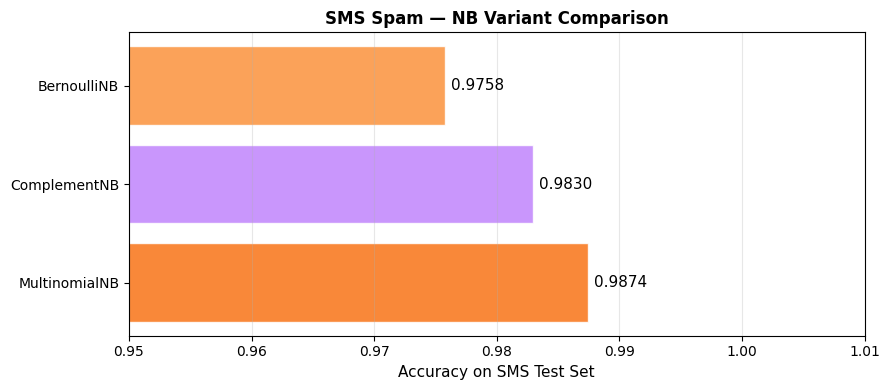

In [18]:
# Accuracy comparison of all text models on SMS Spam
sms_results = {
    'MultinomialNB': accuracy_score(y_test_sms, y_pred_mnb),
    'ComplementNB':  accuracy_score(y_test_sms, y_pred_comp),
    'BernoulliNB':   accuracy_score(y_test_sms, y_pred_bnb),
}

fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ['#f97316', '#c084fc', '#fb923c']
bars = ax.barh(list(sms_results.keys()), list(sms_results.values()),
               color=colors_bar, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=11, padding=4)
ax.set_xlim(0.95, 1.01)
ax.set_xlabel('Accuracy on SMS Test Set', fontsize=11)
ax.set_title('SMS Spam — NB Variant Comparison', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(135deg, #1a0a00 0%, #2d1500 100%); border: 1px solid #4a2800; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Summary — The Naive Bayes Family</h2>
  <p style="color: #fdba74; font-size: 13px; margin: 0 0 20px 0;">Quick reference for choosing the right variant.</p>
  <div style="background: #100800; border: 1px solid #4a2800; border-radius: 10px; overflow: hidden; margin-bottom: 20px;">
    <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
      <thead>
        <tr style="background: #2d1500;">
          <th style="padding: 11px 16px; color: #f97316; text-align: left;">Variant</th>
          <th style="padding: 11px 16px; color: #f97316; text-align: left;">Feature Type</th>
          <th style="padding: 11px 16px; color: #f97316; text-align: left;">Example Dataset</th>
          <th style="padding: 11px 16px; color: #f97316; text-align: center;">This Notebook Acc.</th>
        </tr>
      </thead>
      <tbody>
        <tr style="border-bottom: 1px solid #4a2800;"><td style="padding: 10px 16px; color: #fdba74; font-weight: 600;">🌸 GaussianNB</td><td style="padding: 10px 16px; color: #fdba74;">Continuous numerical</td><td style="padding: 10px 16px; color: #fdba74;">Iris flowers</td><td style="padding: 10px 16px; color: #22c55e; text-align: center; font-weight: 700;">92.1%</td></tr>
        <tr style="border-bottom: 1px solid #4a2800; background: rgba(249,115,22,0.04);"><td style="padding: 10px 16px; color: #fdba74; font-weight: 600;">📱 MultinomialNB</td><td style="padding: 10px 16px; color: #fdba74;">Word counts (integers ≥ 0)</td><td style="padding: 10px 16px; color: #fdba74;">SMS spam</td><td style="padding: 10px 16px; color: #22c55e; text-align: center; font-weight: 700;">98.7%</td></tr>
        <tr style="border-bottom: 1px solid #4a2800;"><td style="padding: 10px 16px; color: #fdba74; font-weight: 600;">📱 BernoulliNB</td><td style="padding: 10px 16px; color: #fdba74;">Binary 0/1 (presence)</td><td style="padding: 10px 16px; color: #fdba74;">SMS spam</td><td style="padding: 10px 16px; color: #f0a500; text-align: center; font-weight: 700;">97.6%</td></tr>
        <tr style="border-bottom: 1px solid #4a2800; background: rgba(249,115,22,0.04);"><td style="padding: 10px 16px; color: #fdba74; font-weight: 600;">🚢 CategoricalNB</td><td style="padding: 10px 16px; color: #fdba74;">Categorical / ordinal labels</td><td style="padding: 10px 16px; color: #fdba74;">Titanic features</td><td style="padding: 10px 16px; color: #f0a500; text-align: center; font-weight: 700;">~78%</td></tr>
        <tr><td style="padding: 10px 16px; color: #fdba74; font-weight: 600;">⚖️ ComplementNB</td><td style="padding: 10px 16px; color: #fdba74;">Counts (imbalanced data)</td><td style="padding: 10px 16px; color: #fdba74;">SMS spam</td><td style="padding: 10px 16px; color: #22c55e; text-align: center; font-weight: 700;">98.3%</td></tr>
      </tbody>
    </table>
  </div>
  <div style="background: #100800; border: 1px solid #4a2800; border-radius: 10px; padding: 18px 20px; font-family: monospace; font-size: 13px; color: #fdba74; line-height: 2; margin-bottom: 16px;">
    <div style="color: #f97316; font-weight: 700; margin-bottom: 8px;">Decision Tree — Naive Bayes Family</div>
    <pre style="color: #fdba74; margin: 0; background: transparent; font-size: 12px;">                 Naive Bayes
                      │
       ┌──────────────┼──────────────┐
       │              │              │
  Numerical         Text        Categorical
       │              │              │
 GaussianNB    ┌──────┴──────┐  CategoricalNB
               │             │
        MultinomialNB    BernoulliNB
               │
          ComplementNB
         (imbalanced)</pre>
  </div>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-bottom: 16px;">
    <div style="background: rgba(249,115,22,0.08); border: 1px solid #4a2800; border-radius: 8px; padding: 14px 16px;">
      <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚡ Advantages</div>
      <div style="color: #fdba74; font-size: 12px; line-height: 1.7;">Extremely fast to train and predict. Works well with small data. Handles high-dimensional features (text). Naturally multi-class.</div>
    </div>
    <div style="background: rgba(249,115,22,0.08); border: 1px solid #4a2800; border-radius: 8px; padding: 14px 16px;">
      <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚠️ Limitations</div>
      <div style="color: #fdba74; font-size: 12px; line-height: 1.7;">Independence assumption is almost never true. Poor probability calibration. Cannot capture feature interactions. Outperformed by ensemble methods on structured data.</div>
    </div>
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #4a2800; color: #fdba74; font-size: 12px;">
    Next up → <strong style='color:#f97316;'>ML 44: K-Nearest Neighbours (KNN) — Distance-Based Classification &amp; Regression</strong>
  </div>
</div>